#  1. CIR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append("./models")

from cir.simulation import DataSimulation
from cir.backtest import ModelBacktester

In [2]:
def read_and_combine_files(file_patterns, asset_name):
    """Читает и объединяет CSV файлы для одного актива"""
    dfs = []
    for file in file_patterns:
        df = pd.read_csv(file, sep=';', skiprows=1, names=['TICKER','PER','DATE','TIME','OPEN','HIGH','LOW','CLOSE','VOL'])
        df['DATE'] = pd.to_datetime(df['DATE'], format='%y%m%d')
        dfs.append(df)
    combined = pd.concat(dfs)[['DATE', 'CLOSE']]
    combined.columns = ['DATE', asset_name]
    return combined

assets = {
    'vxx': ["data/VXX_160101_201231.csv", "data/VXX_210101_260331.csv"],
    'treasures': ["data/SHY_160101_201231.csv", "data/SHY_210101_260331.csv"],
    'snp': ["data/SPX_160101_201231.csv", "data/SPX_210101_260331.csv"]
}

asset_dfs = {}
for name, files in assets.items():
    asset_dfs[name] = read_and_combine_files(files, name)
merged = asset_dfs['vxx']
for name in ['treasures', 'snp']:
    merged = merged.merge(asset_dfs[name], on='DATE', how='inner')
merged = merged.set_index('DATE').sort_index()

vxx = merged['vxx'].values
treasures = merged['treasures'].values
snp = merged['snp'].values

Методы оценки параметров: VIX: log_likelihood_article, Treasuries: ols
Прогноз на 63 дней, 15 симуляций


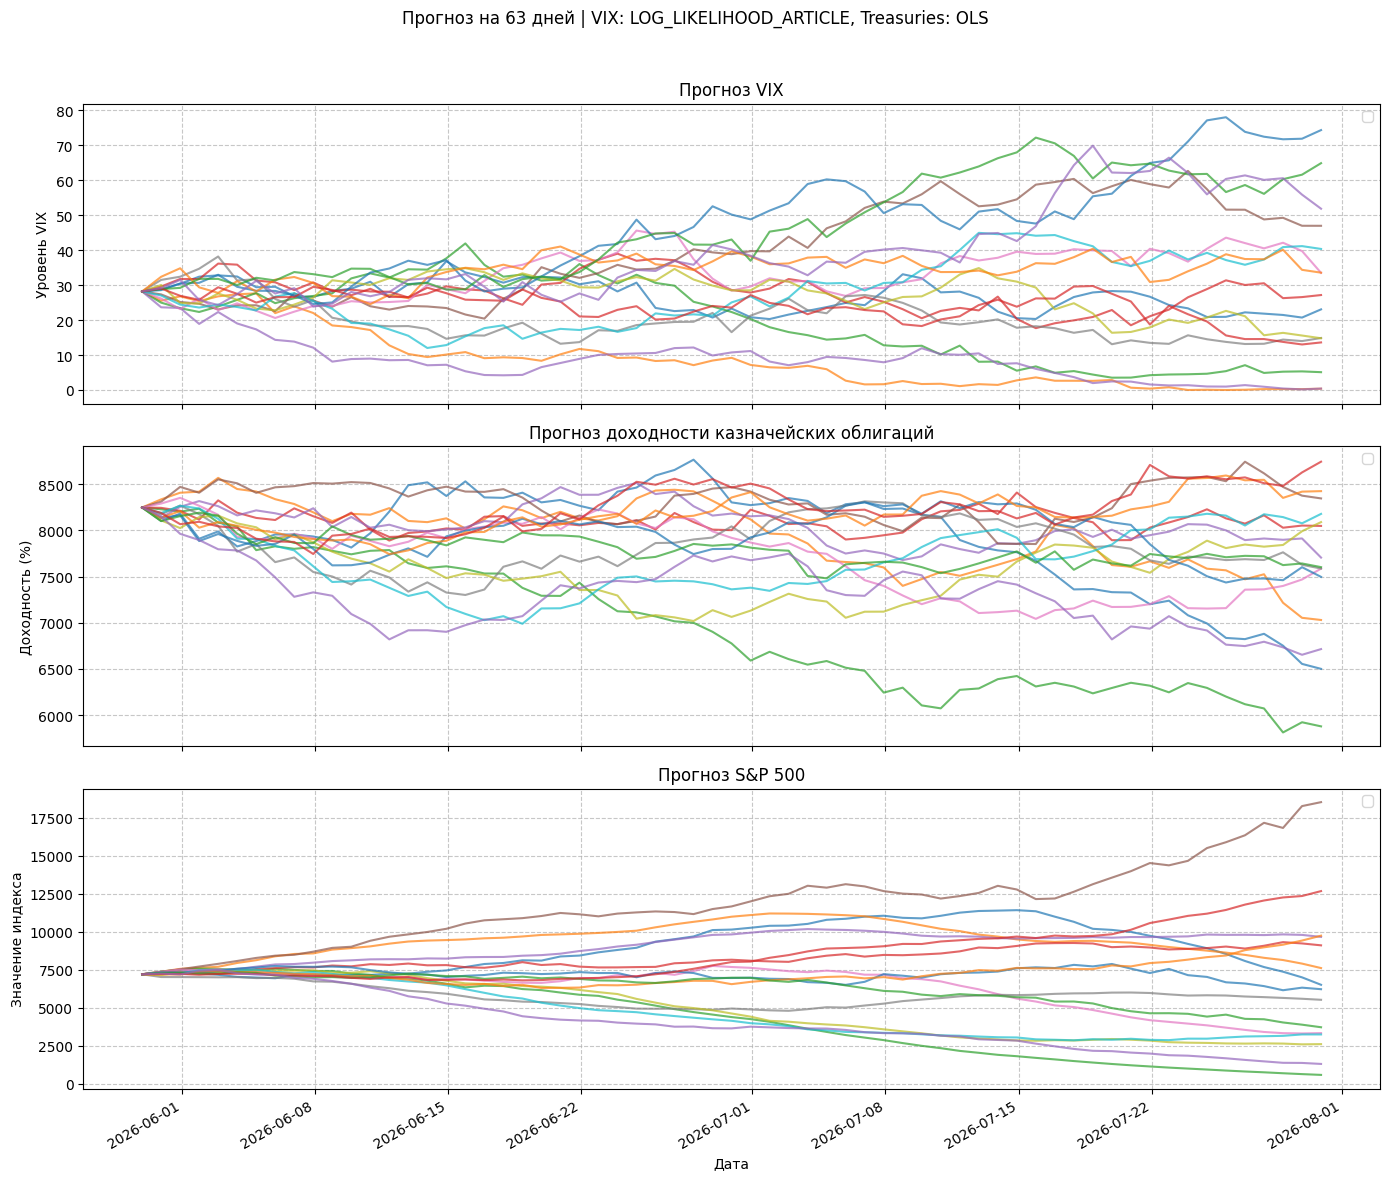

In [3]:
np.random.seed(819946)

n = 800
vxx = merged['vxx'].values[n:]
treasures = merged['treasures'].values[n:]
snp = merged['snp'].values[n:]
 
simulator = DataSimulation(
        vix_array=vxx, 
        treasures_array=treasures, 
        snp_array=snp,
        vix_method='log_likelihood_article',
        treasures_method='ols',
        forecast_days=63,  # Прогноз на 60 дней
        num_simulations=15  # 15 симуляций
    )
    
vix_sim, treas_sim, snp_sim = simulator.get_processes()
simulator.plot_simulations(vix_sim, treas_sim, snp_sim)

In [4]:
def plot_line(array, name):
    plt.figure(figsize=(14, 5)) 
    plt.plot(range(1, len(array) + 1), array, marker='o')
    plt.title(name)
    plt.xlabel('День')
    plt.ylabel('Значение')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

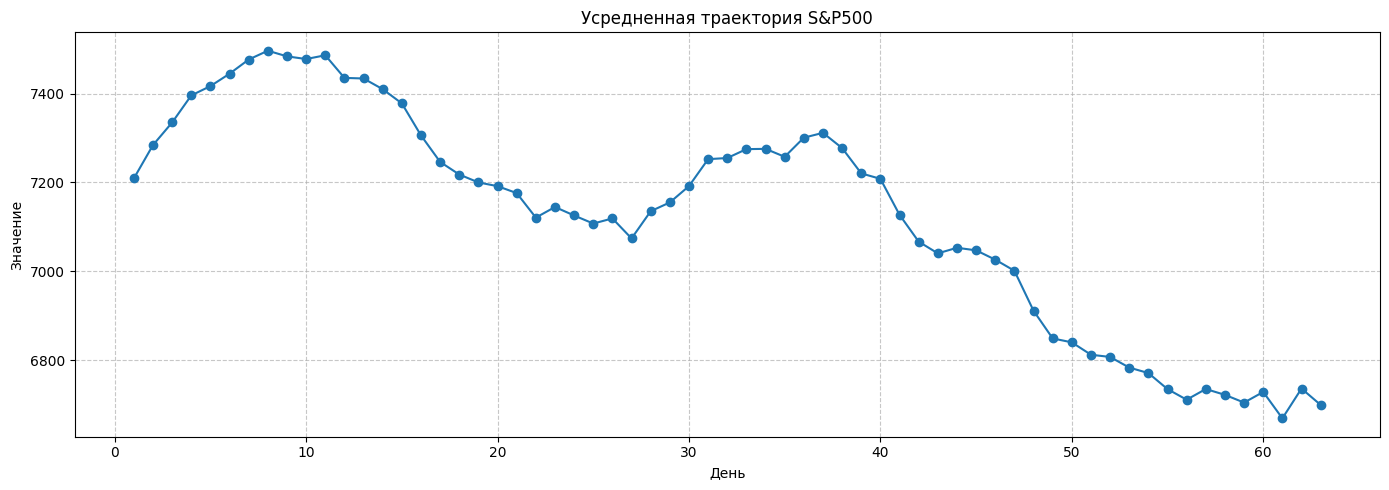

In [5]:
sim_snp_track = snp_sim.mean(axis=1)
plot_line(sim_snp_track, 'Усредненная траектория S&P500')

Запуск бэктеста на 4 периодов...
Обучающее окно: 126 дней, Прогноз: 30 дней
Период 1/4 завершен: обучение до 2024-05-02, прогноз на 30 дней
Период 2/4 завершен: обучение до 2024-12-13, прогноз на 30 дней
Период 3/4 завершен: обучение до 2025-08-04, прогноз на 30 дней
Период 4/4 завершен: обучение до 2026-03-18, прогноз на 30 дней

Бэктест завершен!

Метрики качества прогноза:
MAE: 175.4166
RMSE: 218.2707
MAPE: 2.9849
R2: 0.8649
Correlation: 0.9737
Построение графиков для всех 4 периодов...


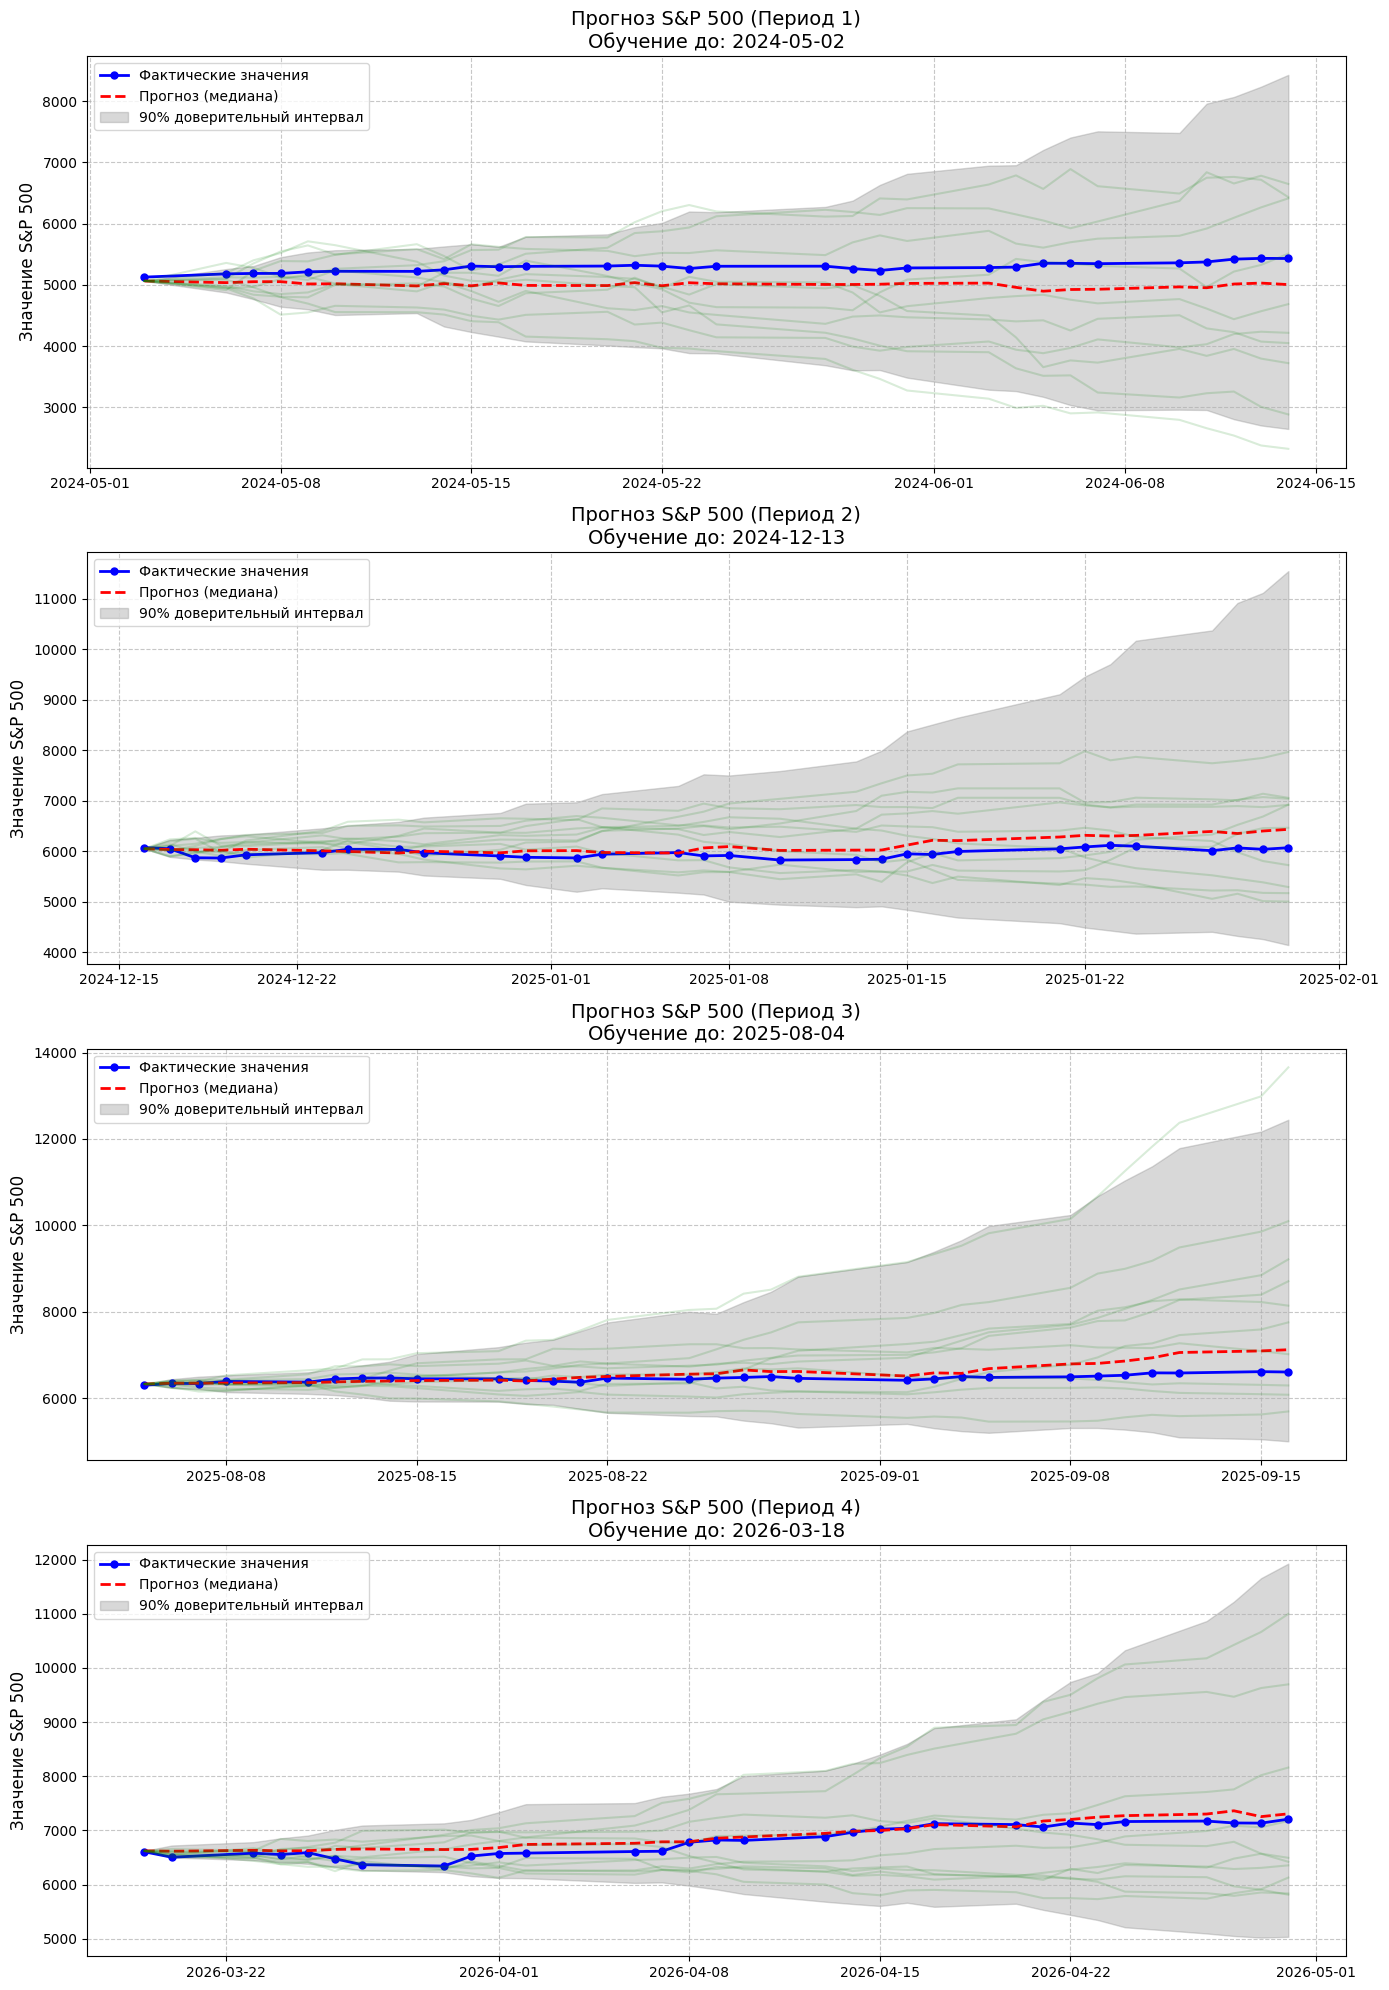

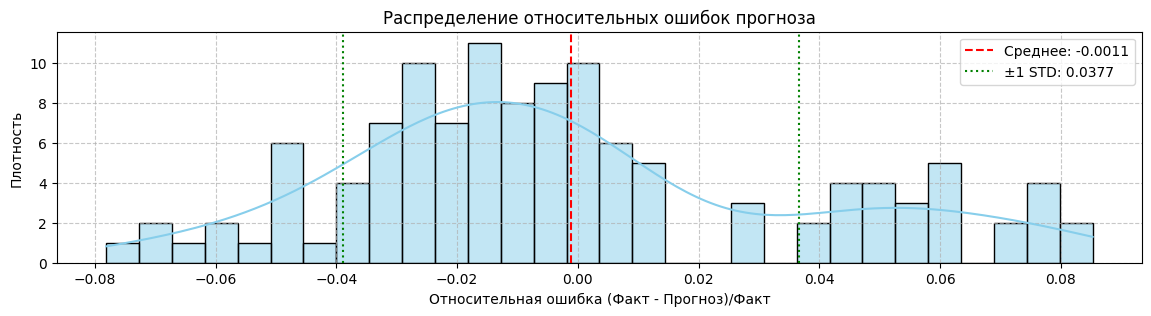

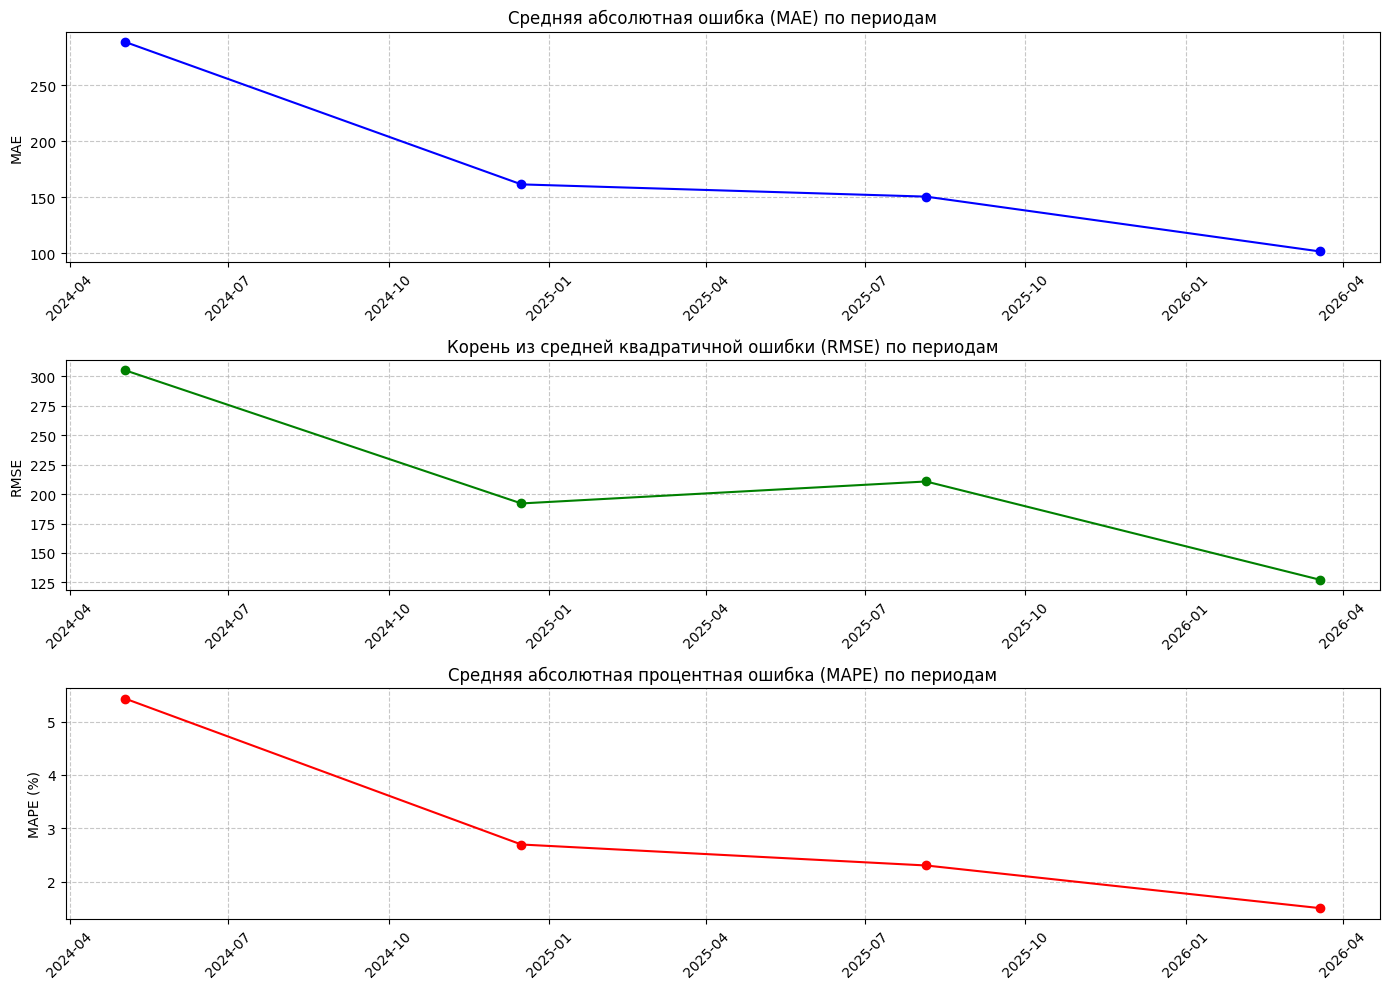


СВОДНЫЙ ОТЧЕТ ПО БЭКТЕСТУ МОДЕЛИ ПРОГНОЗИРОВАНИЯ

Конфигурация модели:
- Метод оценки VIX: log_likelihood_article
- Метод оценки Treasuries: ols
- Окно обучения: 126 дней
- Прогнозный горизонт: 30 дней
- Количество тестовых периодов: 4

Период данных:
- Начало: 2022-09-02
- Конец: 2026-04-30
- Всего дней: 916

Результаты бэктестинга:
- Общее количество прогнозов: 120
- Период первого прогноза: 2024-05-03 - 2024-06-14
- Период последнего прогноза: 2026-03-19 - 2026-04-30

Метрики качества прогноза:
- MAE: 175.4166
- RMSE: 218.2707
- MAPE: 2.9849
- R2: 0.8649
- Correlation: 0.9737


Дополнительный анализ:
Средняя абсолютная ошибка (MAE): 175.42 пунктов S&P 500
Средняя процентная ошибка (MAPE): 2.98%
Корреляция прогноза с реальностью: 0.9737

Метрики по периодам:
   Period Start Date   End Date         MAE        RMSE      MAPE
0       1 2024-05-03 2024-06-14  288.470346  305.136384  5.427891
1       2 2024-12-16 2025-01-30  161.351511  192.059674  2.698622
2       3 2025-08-05 2025-09-1

In [6]:
np.random.seed(42)

n = 1150
# Создание и запуск бэктестера
backtester = ModelBacktester(
        vix_data=merged['vxx'][n :],
        treas_data=merged['treasures'][n :],
        snp_data=merged['snp'][n :],
        train_window=126,    # 1 год обучения
        test_periods=4,      
        forecast_days=30,    # Прогноз на 30 дней
        vix_method='log_likelihood_article',
        treasures_method='ols'
)
    
backtester.run_backtest()
    
backtester.plot_backtest_results(all_periods=True)
backtester.plot_error_distribution()
metrics_df = backtester.plot_metrics_comparison()
        
# Вывод метрик
backtester.print_summary_report()
        
# Дополнительный анализ
print("\nДополнительный анализ:")
print(f"Средняя абсолютная ошибка (MAE): {backtester.metrics['MAE']:.2f} пунктов S&P 500")
print(f"Средняя процентная ошибка (MAPE): {backtester.metrics['MAPE']:.2f}%")
print(f"Корреляция прогноза с реальностью: {backtester.metrics['Correlation']:.4f}")
        
print("\nМетрики по периодам:")
print(metrics_df)

# WGAN NOISE

In [7]:
from models.noise_gan import wgan_gp_residuals

In [8]:
# Загрузка данных
file_list = ["data/SPX_160101_201231.csv", "data/SPX_210101_260331.csv"]
combined_df = read_and_combine_files(file_list, "SPX")
prices = combined_df["SPX"].values

In [9]:
# Обучение модели или загрузка существующей
G, C = wgan_gp_residuals.train_wgan_gp(
    prices,
    num_epochs=2000,
    print_every=200,
    seq_len=30,
)

Working directory: C:\Users\rawen\MyProjects\hse\1 курс\coursepaper\!vkr_repo
Saving to: .
Metrics path: .\metrics_log.csv
Generator path: .\generator.pth
Found metrics_log.csv. Training skipped.


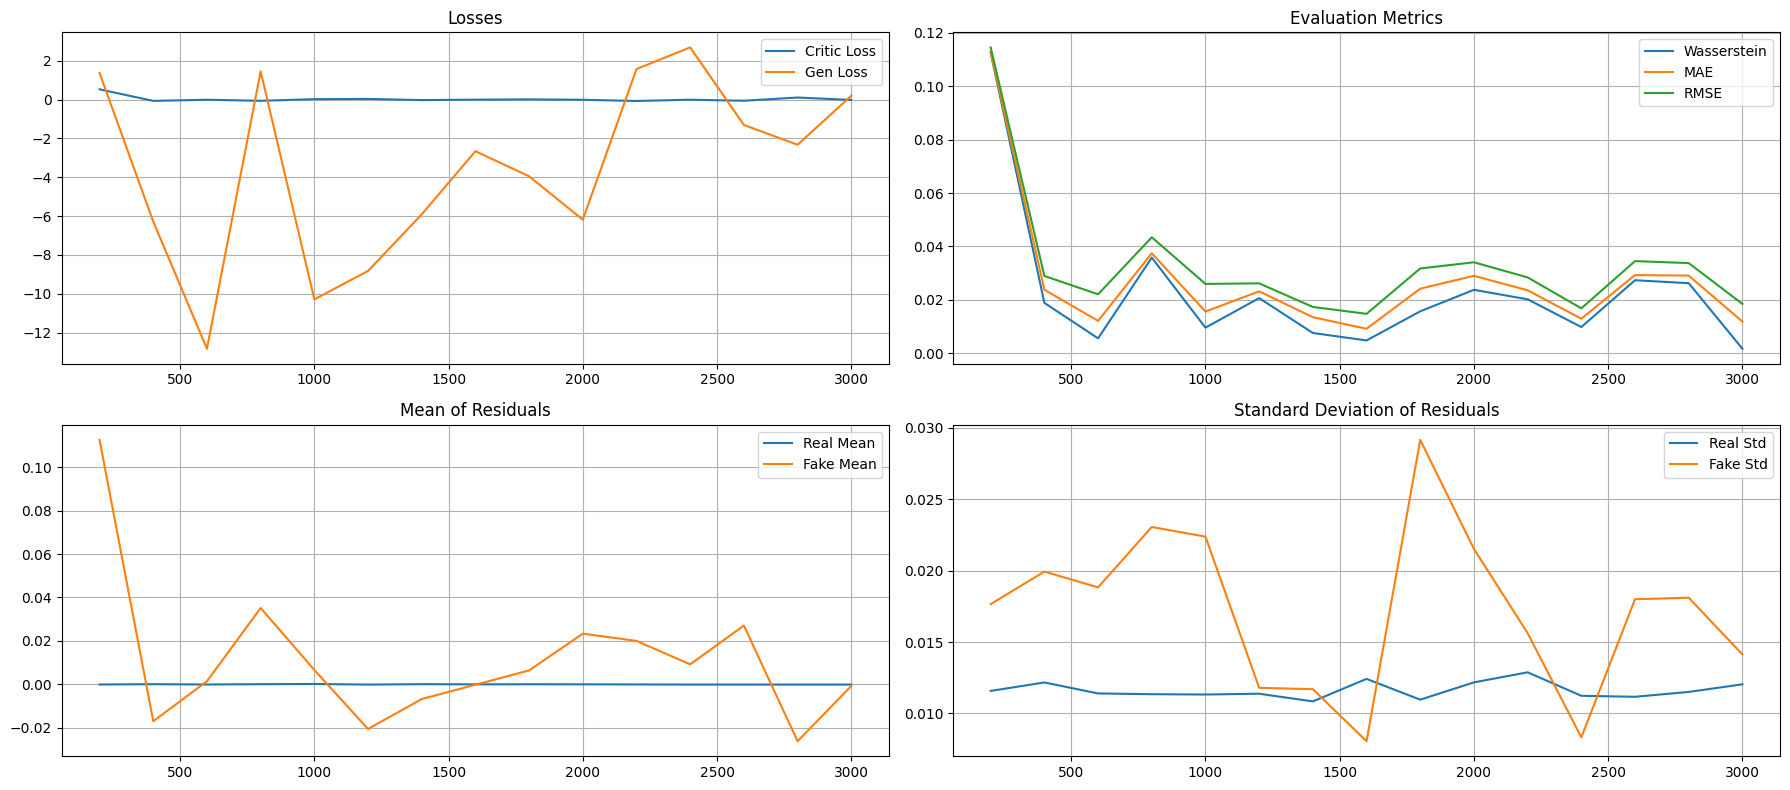

In [10]:
# Визуализация метрик
wgan_gp_residuals.plot_saved_metrics("metrics_log.csv")

# COMBINED

In [11]:
import torch
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from models.noise_gan.wgan_gp_residuals import Generator
from cir.gan_integrated_sim import GANIntegratedSimulation
from combined.backtest import print_final_report, plot_ACF, perform_statistical_validation, check_residuals_stability

noise_dim = 20
seq_len = 30

G = Generator(noise_dim, seq_len)
G.load_state_dict(torch.load("generator.pth")) 

<All keys matched successfully>

In [12]:
MAGIC_SEED = 29140
np.random.seed(MAGIC_SEED)
torch.manual_seed(MAGIC_SEED)

# Инициализация модели
gan_simulator = GANIntegratedSimulation(
    generator=G, 
    noise_dim=20,
    vix_array=vxx, 
    treasures_array=treasures, 
    snp_array=snp,
    vix_method='log_likelihood_article',
    forecast_days=30, 
    num_simulations=15
)

# Генерация процессов
v_sim, t_sim, s_sim = gan_simulator.get_processes()

# Вывод метрик
returns_real = np.diff(np.log(snp[-30:]))
returns_synth = np.diff(np.log(s_sim), axis=0).flatten()

print_final_report(returns_real, returns_synth)


ОТЧЕТ
  Metric  Real S&P 500  Synthetic (GAN+CIR)
    Mean      0.003010             0.003395
 Std Dev      0.010369             0.011543
Skewness      0.169617             0.371104
Kurtosis      0.442551             0.454088
--------------------------------------------------
Точность по Куртозису: 97.39%


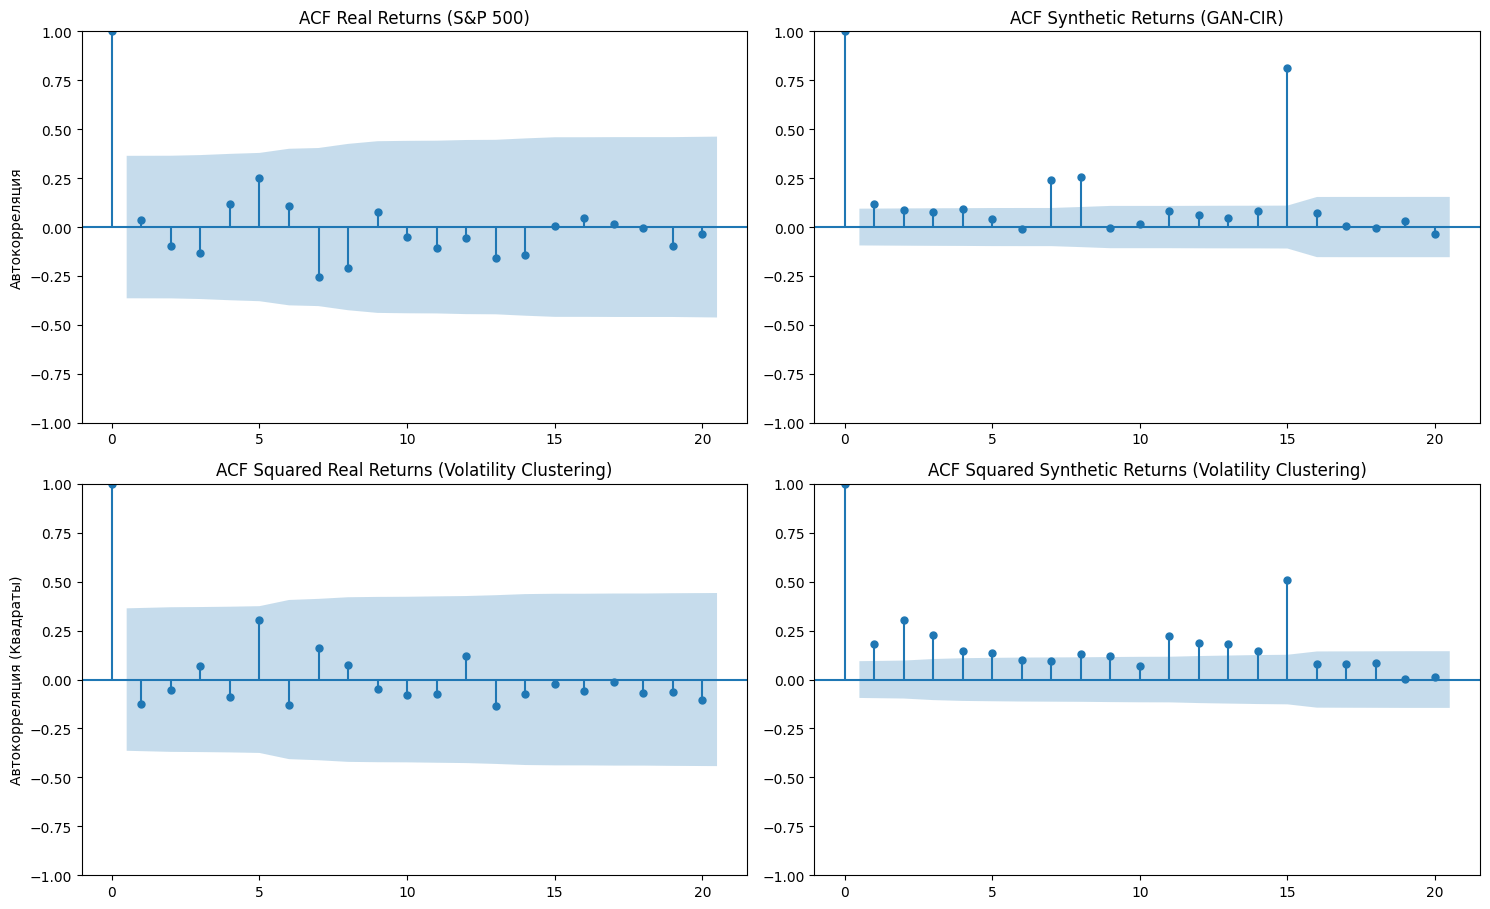

In [13]:
plot_ACF(returns_real, returns_synth)


ОТЧЕТ ПО ВАЛИДАЦИИ
Hit Ratio (95% CI): 93.33%
KS-statistic: 0.6800
P-value: 0.0000
----------------------------------------
Ура


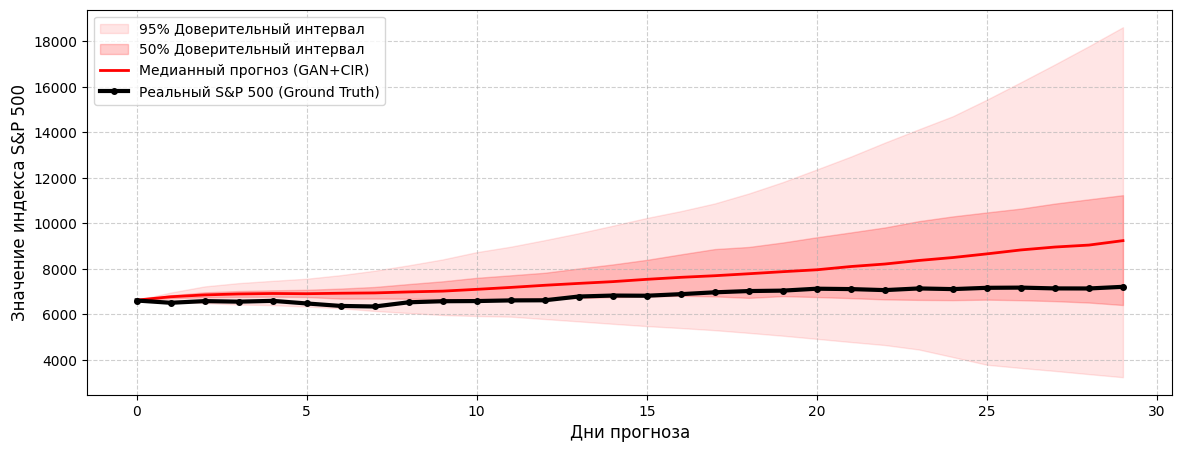

In [14]:
MAGIC_SEED = 29140
np.random.seed(MAGIC_SEED)
torch.manual_seed(MAGIC_SEED)

forecast_len = 30
snp_train = snp[:-forecast_len]
snp_test = snp[-forecast_len:]
vxx_train = vxx[:-forecast_len]
treasures_train = treasures[:-forecast_len]

backtest_sim = GANIntegratedSimulation(
    generator=G, 
    noise_dim=20,
    vix_array=vxx_train, 
    treasures_array=treasures_train, 
    snp_array=snp_train,
    vix_method='log_likelihood_article',
    forecast_days=forecast_len,
    num_simulations=100
)

_, _, s_sim_backtest = backtest_sim.get_processes()

perform_statistical_validation(snp_test, s_sim_backtest)

In [15]:
check_residuals_stability(returns_synth)

Durbin-Watson statistic: 1.5899

ИТОГ: Наблюдается положительная автокорреляция.
